<a href="https://colab.research.google.com/github/NiteshJ98/LLM-from-scratch/blob/main/Tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Section 1 — Creating tensors



In [1]:
import torch

# From Python lists
a = torch.tensor([1.0, 2.0, 3.0])
print(a)          # tensor([1., 2., 3.])
print(a.shape)    # torch.Size([3])
print(a.dtype)    # torch.float32

tensor([1., 2., 3.])
torch.Size([3])
torch.float32


In [2]:
# 2D tensor (matrix)
b = torch.tensor([[1, 2, 3],
                  [4, 5, 6]])
print(b.shape)    # torch.Size([2, 3]) — 2 rows, 3 columns

torch.Size([2, 3])


In [3]:
# Filled with zeros / ones
zeros = torch.zeros(3, 4)     # shape (3, 4), all 0.0
ones  = torch.ones(2, 5)      # shape (2, 5), all 1.0
print(zeros)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])


In [4]:
# Random tensors — the ones you'll use most
rand  = torch.rand(3, 3)      # uniform random [0, 1)
randn = torch.randn(3, 3)     # standard Gaussian — used in weight init
print(rand)
print(randn)

tensor([[0.5082, 0.3391, 0.0731],
        [0.8508, 0.5879, 0.7693],
        [0.7361, 0.9488, 0.6815]])
tensor([[-1.4328,  0.8545, -0.3147],
        [-0.1473,  0.3963,  0.6041],
        [-0.0930, -0.4476, -1.2579]])


In [5]:
# Like an existing tensor (same shape/device, new values)
zeros_like = torch.zeros_like(b.float())
ones_like  = torch.ones_like(b.float())
print(zeros_like)
print(ones_like)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [6]:
# Range (like Python's range)
r = torch.arange(0, 10, 2)   # tensor([0, 2, 4, 6, 8])
print(r)

tensor([0, 2, 4, 6, 8])


The three attributes you check constantly:

In [8]:
x = torch.randn(4, 8)

print(x)
print(x.shape)    # torch.Size([4, 8])  — dimensions
print(x.dtype)    # torch.float32       — number type
print(x.device)   # cpu                 — where it lives

tensor([[-1.1595,  1.6067,  0.1642, -1.0162,  0.6966,  1.3123,  0.2336,  0.8947],
        [ 0.5006, -0.4832,  0.4473,  0.8542,  0.7624, -0.4032, -0.6114,  2.3362],
        [ 1.8179, -0.8341,  0.1109, -0.6197, -0.5762,  0.1847,  0.0852,  0.9667],
        [ 0.2108,  0.8821, -0.9240,  0.1320,  2.0205,  1.0011, -0.8251, -0.2951]])
torch.Size([4, 8])
torch.float32
cpu


**Section 2 — Shapes and reshaping**

Shape is the most important thing to track. Mismatched shapes cause 90% of PyTorch errors.

In [12]:
x = torch.arange(24).float()

print(x)
print(x.shape)   # torch.Size([24]) — flat list of 24 numbers
print(x.dtype)

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23.])
torch.Size([24])
torch.float32


In [13]:
# Reshape — total elements must stay the same (24 = 24)
a = x.reshape(4, 6)     # (4, 6)   — 4 rows of 6
b = x.reshape(2, 3, 4)  # (2, 3, 4) — 3D
c = x.reshape(24, 1)    # (24, 1)  — column vector
d = x.reshape(1, 24)    # (1, 24)  — row vector

In [14]:
# -1 means "figure it out" — very convenient
e = x.reshape(6, -1)    # (6, 4)   — PyTorch computes the 4
f = x.reshape(-1, 8)    # (3, 8)   — PyTorch computes the 3

In [18]:
print(b)

tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]],

        [[12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.]]])


unsqueeze is extremely common in deep learning — you use it to add a batch dimension or make shapes compatible for broadcasting.

In [19]:
# Squeeze / unsqueeze — add or remove size-1 dimensions
g = torch.randn(3, 1, 4)

print(g)
print(g.squeeze().shape)      # (3, 4)   — removes the 1
print(g.squeeze(1).shape)     # (3, 4)   — removes dim 1 specifically

tensor([[[ 0.0258, -0.7302,  0.1393,  0.9998]],

        [[ 0.4376,  1.9639, -0.4514,  1.5011]],

        [[-2.0916, -0.0043,  0.3432,  0.1229]]])
torch.Size([3, 4])
torch.Size([3, 4])


In [23]:
g= torch.randn(3,2,4)

print(g)
print(g.squeeze().shape)
print(g.squeeze(2).shape)

tensor([[[-0.1170, -0.4497, -1.3758, -0.8614],
         [ 0.1198, -1.0291, -1.9227,  0.5654]],

        [[ 0.1181,  0.0189,  0.6917, -0.6551],
         [-0.3082, -0.1237, -0.0389,  0.2460]],

        [[ 1.0125,  0.5369,  0.0881, -2.0932],
         [-0.5913, -1.7804,  0.0063,  0.3946]]])
torch.Size([3, 2, 4])
torch.Size([3, 2, 4])


In [29]:
# Example tensor with dimensions of size 1
x = torch.randn(1, 5, 1, 10, 1)
#print(x)
print(f"Original tensor x shape: {x.shape}")

# Using squeeze() without arguments: removes all dimensions of size 1
y_squeezed_all = x.squeeze()
#print(f"After x.squeeze(): {y_squeezed_all}")
print(f"Shape after x.squeeze(): {y_squeezed_all.shape}")

# Using squeeze(dim) to remove a specific dimension of size 1
# Let's squeeze dimension 0 (the first '1')
y_squeezed_dim0 = x.squeeze(0)
print(f"Shape after x.squeeze(0): {y_squeezed_dim0.shape}")

# Let's squeeze dimension 2 (the second '1' in the original shape)
y_squeezed_dim2 = x.squeeze(2)
print(f"Shape after x.squeeze(2): {y_squeezed_dim2.shape}")

# If you try to squeeze a dimension that is not of size 1, it will have no effect
y_squeezed_dim1 = x.squeeze(1) # Dimension 1 has size 5, not 1
print(f"Shape after x.squeeze(1): {y_squeezed_dim1.shape}")

Original tensor x shape: torch.Size([1, 5, 1, 10, 1])
Shape after x.squeeze(): torch.Size([5, 10])
Shape after x.squeeze(0): torch.Size([5, 1, 10, 1])
Shape after x.squeeze(2): torch.Size([1, 5, 10, 1])
Shape after x.squeeze(1): torch.Size([1, 5, 1, 10, 1])


In [31]:
h = torch.randn(3, 4)

print(h)
print(h.unsqueeze(0).shape)   # (1, 3, 4) — adds dim at position 0
print(h.unsqueeze(1).shape)   # (3, 1, 4) — adds dim at position 1
print(h.unsqueeze(-1).shape)  # (3, 4, 1) — adds dim at the end

tensor([[-0.0302, -0.8779,  0.5744,  0.4171],
        [ 1.0055, -1.3521, -0.2422, -0.5609],
        [-1.7014,  0.5968, -0.0787, -2.7373]])
torch.Size([1, 3, 4])
torch.Size([3, 1, 4])
torch.Size([3, 4, 1])


In [34]:
# Transpose — swap two dimensions
m = torch.randn(3, 5)       # shape (3, 5)
print(m)
print(m.shape)
print(m.T.shape)             # shape (5, 3) — full transpose
print(m.transpose(0,1).shape) # same thing, explicit

tensor([[ 1.4163, -0.6793,  0.1189,  0.5099,  0.2728],
        [ 0.4755, -0.0020, -0.2839, -0.3769,  1.5612],
        [-0.7236,  0.1697, -0.1113,  0.3405,  0.3555]])
torch.Size([3, 5])
torch.Size([5, 3])
torch.Size([5, 3])


In [35]:
# permute — reorder all dimensions at once
t = torch.randn(2, 3, 4)
print(t.permute(2, 0, 1).shape)  # (4, 2, 3) — rearranged

torch.Size([4, 2, 3])


Section 3 — Operations

In [ ]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

# Element-wise — same shape, operates element by element
print(a + b)      # tensor([5., 7., 9.])
print(a * b)      # tensor([4., 10., 18.])
print(a - b)      # tensor([-3., -3., -3.])
print(a / b)      # tensor([0.25, 0.4, 0.5])
print(a ** 2)     # tensor([1., 4., 9.])

# Scalar operations — broadcast the scalar to every element
print(a + 10)     # tensor([11., 12., 13.])
print(a * 3)      # tensor([3., 6., 9.])

In [36]:
# Reduction — collapses dimensions
x = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])   # shape (2, 3)

print(x.sum())           # tensor(21.)        — sum everything
print(x.sum(dim=0))      # tensor([5., 7., 9.]) — sum along rows → shape (3,)
print(x.sum(dim=1))      # tensor([6., 15.])   — sum along cols → shape (2,)
print(x.mean())          # tensor(3.5)
print(x.max())           # tensor(6.)
print(x.argmax())        # tensor(5) — index of max in flattened tensor
print(x.argmax(dim=1))   # tensor([2, 2]) — index of max per row

# Matrix multiplication — the most important operation in deep learning
A = torch.randn(3, 4)   # (3, 4)
B = torch.randn(4, 5)   # (4, 5)
C = A @ B               # (3, 5) — inner dimensions must match
# equivalent: torch.matmul(A, B)

tensor(21.)
tensor([5., 7., 9.])
tensor([ 6., 15.])
tensor(3.5000)
tensor(6.)
tensor(5)
tensor([2, 2])


In [37]:
# Dot product (1D only)
u = torch.tensor([1.0, 2.0, 3.0])
v = torch.tensor([4.0, 5.0, 6.0])
print(u @ v)   # tensor(32.) = 1*4 + 2*5 + 3*6

tensor(32.)


Every linear layer in a neural network is just output = input @ weight.T + bias. That @ is where all the computation lives.

In [ ]:
w=torch.tensor([1,2,3])
x=torch.tessor([[]])

**Section 4 — Broadcasting**

Broadcasting is how PyTorch handles operations between tensors of different shapes. Instead of throwing an error, it "stretches" the smaller tensor to match the larger one — conceptually, not by copying memory.

***Broadcasting:***

This is a powerful mechanism in PyTorch (and NumPy) that allows operations between tensors of different shapes. We discussed how PyTorch automatically expands the smaller tensor's dimensions to match the larger one, provided they are compatible. The rule is: starting from the rightmost dimension, two dimensions are compatible if they are equal, or one of them is 1. If a dimension is 1, it's 'stretched' to match the other tensor's dimension. This explains how you can add a (1,3) row vector to a (3,1) column vector to get a (3,3) result.

In [38]:
import torch

# Create a 1D tensor
x = torch.tensor([1, 2, 3])
print(f"Original tensor: {x}")
print(f"Original shape: {x.shape}")

# Create a row vector (1, 3) by unsqueezing at dimension 0
row_vector = x.unsqueeze(0)
print(f"\nRow vector: {row_vector}")
print(f"Shape of row vector: {row_vector.shape}")

# Create a column vector (3, 1) by unsqueezing at dimension 1 (or -1)
column_vector = x.unsqueeze(1)
print(f"\nColumn vector: {column_vector}")
print(f"Shape of column vector: {column_vector.shape}")

Original tensor: tensor([1, 2, 3])
Original shape: torch.Size([3])

Row vector: tensor([[1, 2, 3]])
Shape of row vector: torch.Size([1, 3])

Column vector: tensor([[1],
        [2],
        [3]])
Shape of column vector: torch.Size([3, 1])


In [40]:
result = row_vector + column_vector

print(row_vector)
print(column_vector)
print(result)

tensor([[1, 2, 3]])
tensor([[1],
        [2],
        [3]])
tensor([[2, 3, 4],
        [3, 4, 5],
        [4, 5, 6]])


In [44]:
# Case 2 — the one you'll see in every neural network
activations = torch.randn(32, 768)  # batch of 32, hidden size 768
bias        = torch.randn(768)      # one bias per feature

out = activations + bias   # bias broadcasts across the 32 examples
#print(activations)
#print(bias)
print(out.shape)           # torch.Size([32, 768])

torch.Size([32, 768])


In [45]:
# Case 3 — outer product via broadcasting
col = torch.tensor([[1.], [2.], [3.]])   # shape (3, 1)
row = torch.tensor([[10., 20., 40.]])    # shape (1, 3)

print(col + row)
# tensor([[11., 21., 41.],
#         [12., 22., 42.],
#         [13., 23., 43.]])
# shape: (3, 3)

# The broadcasting rule: align from the right, stretch size-1 dims
# (3,1) + (1,3) → (3,3) ✓
# (3,4) + (3,5) → ERROR ✗  (4 and 5 are both > 1 and not equal)

tensor([[11., 21., 41.],
        [12., 22., 42.],
        [13., 23., 43.]])


**Section 5 — Moving to GPU**

***GPU Device Management:***

 We covered how to efficiently use your GPU (Graphics Processing Unit) for computations:

torch.cuda.is_available(): This checks if a CUDA-enabled

GPU is present on your system.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'): This is a common pattern to create a device object that automatically selects the GPU if available, or falls back to the CPU.

We also addressed a common issue in Colab: if torch.cuda.is_available() returns False, you need to manually enable the GPU runtime in Colab's settings (Runtime -> Change runtime type -> GPU).

To demonstrate moving data, we resolved a NameError by defining placeholder model, inputs, and labels before moving them to the device

**Other Tensor Operations:**

We also touched upon:-

**In-place operations:**

Methods ending with an underscore (e.g., add_()) modify the tensor directly, while methods without the underscore (add()) return a new tensor.
Tensor vs. NumPy: PyTorch tensors and NumPy arrays can share memory when converting between them on the CPU (e.g., tensor.numpy()), meaning changes in one affect the other. Safe conversions involve .clone() or .detach().numpy().

**Gradients:**

PyTorch tensors can track gradients (requires_grad=True) which is fundamental for backpropagation in neural networks. You can disable gradient tracking using with torch.no_grad(): for operations where gradients are not needed (e.g., during inference), saving memory and speeding up computation.

In [2]:
import torch
# Check if GPU is available
print(torch.cuda.is_available())   # True on Kaggle/Colab

# Create a device object — use this pattern everywhere
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)   # cuda

True
cuda


In [3]:
# Move a tensor to GPU
x = torch.randn(3, 4)
x_gpu = x.to(device)
print(x_gpu.device)   # cuda:0

cuda:0


In [4]:
import torch.nn as nn

# Create directly on GPU
y = torch.randn(3, 4, device=device)

# Operations between tensors must be on the same device
# This will ERROR:
# z = x + x_gpu   # RuntimeError: expected scalar type ... on CPU got CUDA

# Move back to CPU (e.g. to convert to numpy or print nicely)
x_back = x_gpu.cpu()
print(x_back.device)   # cpu

cpu


In [5]:
# The pattern you use in every training loop:
# FIX: Define 'model', 'inputs', and 'labels' before using them
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(4, 1)
    def forward(self, x):
        return self.linear(x)

model = SimpleModel() # Instantiate your model
inputs = torch.randn(10, 4) # Example input tensor
labels = torch.randn(10, 1) # Example labels tensor

model = model.to(device)
inputs = inputs.to(device)
labels = labels.to(device)
outputs = model(inputs)   # everything on same device — works
print(f"Outputs shape: {outputs.shape}")

Outputs shape: torch.Size([10, 1])


In [6]:
# How much memory is used / available
print(torch.cuda.memory_allocated() / 1e9, "GB used")
print(torch.cuda.memory_reserved() / 1e9,  "GB reserved")

# Free up memory between experiments
import gc
del model
gc.collect()
torch.cuda.empty_cache()

0.008523264 GB used
0.023068672 GB reserved


Section 6 — The things that trip beginners up

In [7]:
# 1. In-place vs out-of-place operations
x = torch.tensor([1.0, 2.0, 3.0])
x.add_(1)    # in-place — modifies x directly (trailing _ means in-place)
print(x)     # tensor([2., 3., 4.])

y = x.add(1) # out-of-place — returns new tensor, x unchanged
print(x)     # tensor([2., 3., 4.])  — same
print(y)     # tensor([3., 4., 5.])  — new

# In-place ops can break autograd — avoid them inside the model

tensor([2., 3., 4.])
tensor([2., 3., 4.])
tensor([3., 4., 5.])


In [8]:
# 2. Tensor vs numpy — sharing memory on CPU
import numpy as np
a = torch.tensor([1.0, 2.0, 3.0])
n = a.numpy()      # shares memory with a!
n[0] = 99
print(a)           # tensor([99.,  2.,  3.]) — a changed too!

# Safe conversion: use .clone() first or .detach().numpy()
n_safe = a.clone().numpy()

tensor([99.,  2.,  3.])


Certainly! This code snippet demonstrates a crucial aspect of interoperability between PyTorch tensors and NumPy arrays: memory sharing on the CPU.

Let's break down the code:

import numpy as np: Imports the NumPy library, commonly aliased as np.

a = torch.tensor([1.0, 2.0, 3.0]): Creates a PyTorch tensor a with the values [1.0, 2.0, 3.0].

n = a.numpy(): This is the key line. When you call .numpy() on a PyTorch tensor that resides on the CPU, it returns a NumPy array n that shares the same underlying memory as the original tensor a.

n[0] = 99: Here, we modify the first element of the NumPy array n to 99.

print(a): When we print the original PyTorch tensor a, you see tensor([99., 2., 3.]). This clearly shows that modifying n also modified a because they are looking at the same data in memory.

 Safe conversion: use .clone() first or .detach().numpy(): This comment highlights how to perform a conversion without memory sharing, which is often desirable to avoid unintended side effects.

.clone().numpy(): Creates a completely separate copy of the tensor before converting it to a NumPy array. Changes to the NumPy array will not affect the original tensor.
.detach().numpy(): The .detach() method creates a new tensor that shares the same storage as the original tensor but does not track gradients. Then, .numpy() converts this detached tensor to a NumPy array. This is useful when you want to convert a tensor from a computation graph to NumPy without impacting the original tensor's gradient tracking, but it still shares memory. If you want a truly independent copy and are concerned about future modifications to the NumPy array affecting the original tensor, .clone().numpy() is generally safer.
In essence, be mindful when converting PyTorch tensors to NumPy arrays on the CPU, as direct conversion (.numpy()) can lead to unexpected changes in your original tensor if the NumPy array is modified.

what is the difference between clone and detach
That's a great question, as clone() and detach() are fundamental for managing PyTorch tensors and their interaction with the computation graph.

Let's break down the differences:

**tensor.detach()**
Purpose: detach() creates a new tensor that shares the same underlying data with the original tensor but is detached from the computation graph. This means that no gradients will be computed for this new tensor, and it will not contribute to the gradient flow back to the original tensor. Think of it as severing the connection to its history in the graph.
Memory Sharing: The new tensor created by detach() shares memory with the original tensor. If you modify the detached tensor (and the original tensor is on the CPU and not leaf node), it can potentially modify the original tensor's data, which can lead to unexpected behavior if not handled carefully.

**Use Cases:**
When you need to get a tensor out of the computation graph for operations where you don't want gradient tracking (e.g., converting a tensor to a NumPy array for visualization or logging, or using a tensor as a constant in a calculation).
When you want to prevent gradients from flowing back through a specific part of your model.
As seen in the previous example, tensor.detach().numpy() is a common way to convert a tensor to a NumPy array, preserving the memory sharing but ensuring no gradient tracking is attempted for the NumPy part.

**tensor.clone()**
Purpose: clone() creates a new tensor that is a deep copy of the original tensor. This new tensor has its own separate memory. Crucially, the new tensor does retain its connection to the computation graph, meaning it has a grad_fn and will still track gradients (if the original tensor had requires_grad=True).
Memory Sharing: The new tensor created by clone() does not share memory with the original tensor. Modifications to the cloned tensor will not affect the original tensor, and vice versa.

**Use Cases:**
When you need an independent copy of a tensor that you can modify without affecting the original.
When you want to perform operations that might modify the tensor in-place, but you still need the original tensor's values untouched for subsequent calculations or gradient computations.
To get a truly independent NumPy array from a PyTorch tensor, you would use tensor.clone().numpy(). This ensures that even if you modify the NumPy array, the original PyTorch tensor remains unchanged.

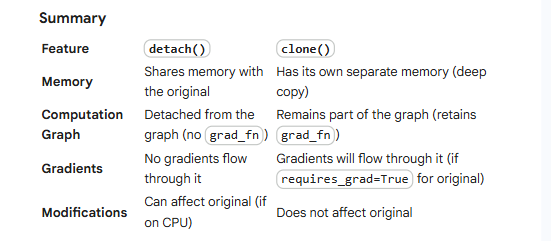

In short: Use detach() when you want to remove a tensor from the gradient flow but are okay with potential memory sharing. Use clone() when you need a completely independent copy of the tensor, especially if you intend to modify it.

In [ ]:
# 3. Gradients — by default tensors don't track them
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()
print(x.grad)   # tensor(6.) — dy/dx = 2x = 6

# When you don't want gradient tracking (e.g. inference):
with torch.no_grad():
    z = x ** 2   # no gradient computation — faster, less memory

The computation graph and grad_fn are fundamental concepts in PyTorch's automatic differentiation engine (autograd), which is what allows neural networks to learn.

**The Computation Graph**
Imagine you're building a recipe. Each ingredient is a piece of data (a tensor), and each step in the recipe (adding, multiplying, applying a function) is an operation that takes ingredients and produces a new one. The computation graph is essentially PyTorch's way of recording this recipe, showing how tensors are created as a result of various operations.

**Definition:** It's a directed acyclic graph (DAG) where:
Nodes represent tensors (the data).
Edges represent the operations (functions) that produced those tensors.

**Purpose:** PyTorch builds this graph dynamically as you perform operations on tensors. This graph stores all the operations that connect the input data to the final output (e.g., the loss function in a neural network).
Automatic Differentiation (Autograd): The main reason PyTorch builds this graph is for automatic differentiation, also known as backpropagation. Once the forward pass (computing the output) is complete and you have a final scalar value (like a loss), you can call .backward() on it. PyTorch then traverses the computation graph backward, from the output back to the inputs, calculating the gradient of the output with respect to each input tensor along the way. These gradients tell us how much each input parameter contributed to the final output, which is crucial for updating model weights during training.

**Dynamic Nature:** PyTorch's graph is 'dynamic' or 'define-by-run', meaning it's built on the fly as your code executes. This makes it very flexible, allowing for control flow (if statements, loops) within your model, which static graphs (like in older TensorFlow versions) struggled with.
grad_fn
Now, how does PyTorch know which operation was performed at each step in the graph? That's where grad_fn comes in.

**Definition:** Every tensor that is not a leaf node (i.e., it was created as a result of some operation, not directly by the user) will have a grad_fn attribute. This attribute points to the function (or operation) that created the tensor.

**Role in Backpropagation:** When .backward() is called, PyTorch uses the grad_fn of each tensor to determine how to compute the gradients for the tensors that were its inputs. Each grad_fn object knows how to perform the backward (gradient) computation for its corresponding forward operation. For example:
If y = x + 2, then y would have a grad_fn like <AddBackward0>. When backpropagating, this AddBackward0 function knows that the gradient of y with respect to x is simply 1 (assuming no other operations).
If y = x * 2, y would have a grad_fn like <MulBackward0>. This MulBackward0 would compute the gradient of y with respect to x as 2.
Leaf Tensors: Tensors that you create directly (e.g., x = torch.tensor(3.0, requires_grad=True)) are considered 'leaf' tensors. They do not have a grad_fn because they weren't produced by any previous operation. You can check if a tensor is a leaf node with tensor.is_leaf.
Let's revisit our example:

x = torch.tensor(3.0, requires_grad=True) # x is a leaf tensor
y = x ** 2 # y is created by an operation, so it has a grad_fn
y.backward()
print(x.grad) # This uses the graph traced via y's grad_fn

*In this simple case:*

x is a leaf tensor; x.is_leaf is True, x.grad_fn is None.
y = x ** 2 means y was created by the power operation. So, y.is_leaf is False, and y.grad_fn would be something like <PowBackward0>.
When y.backward() is called, PyTorch looks at y's grad_fn. <PowBackward0> knows how to compute the derivative of x^2 with respect to x, which is 2x. Since x=3, the gradient computed for x is 2 * 3 = 6.




In [9]:
# 4. dtype matters — mixing float32 and float64 causes errors
a = torch.tensor([1.0])          # float32 by default
b = torch.tensor([1.0], dtype=torch.float64)
# a + b → error in some ops. Cast explicitly:
a = a.float()    # → float32
b = b.double()   # → float64

In [16]:
import torch

# Shapes
x = torch.randn(2, 3, 4)
print(x)
print(x.shape)               # 1
print(x.reshape(6, 4).shape) # 2
print(x.reshape(2, -1).shape)# 3
print(x.permute(2,0,1).shape)# 4
print(x[0].shape)            # 5 — first slice
print(x[:, 1, :].shape)      # 6 — middle dim slice
print(x.unsqueeze(0).shape)  # 7
print(x.squeeze().shape)     # 8 — no size-1 dims, unchanged

tensor([[[-0.3762,  0.8642, -1.1857,  0.0989],
         [-0.1258,  0.7435, -0.3894,  0.6275],
         [-0.0333, -0.3274, -0.3482, -0.9552]],

        [[-0.3236, -0.8682,  0.3321,  0.5033],
         [ 0.9523,  2.3423,  0.8934,  0.0064],
         [ 2.4428, -0.4430, -0.7823, -0.3068]]])
torch.Size([2, 3, 4])
torch.Size([6, 4])
torch.Size([2, 12])
torch.Size([4, 2, 3])
torch.Size([3, 4])
torch.Size([2, 4])
torch.Size([1, 2, 3, 4])
torch.Size([2, 3, 4])


In [11]:
# Operations
a = torch.arange(6).float().reshape(2, 3)
print(a.sum())               # 9
print(a.sum(dim=0))          # 10
print(a.sum(dim=1))          # 11
print(a.mean(dim=0))         # 12
print(a.max())               # 13
print(a.argmax(dim=1))       # 14

tensor(15.)
tensor([3., 5., 7.])
tensor([ 3., 12.])
tensor([1.5000, 2.5000, 3.5000])
tensor(5.)
tensor([2, 2])


In [12]:
# Matrix multiply
A = torch.randn(4, 5)
B = torch.randn(5, 3)
print((A @ B).shape)         # 15

torch.Size([4, 3])


In [13]:
# Broadcasting
p = torch.ones(3, 1)
q = torch.ones(1, 4)
print((p + q).shape)         # 16
print((p * q).shape)         # 17

torch.Size([3, 4])
torch.Size([3, 4])


In [14]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(3, 3).to(device)
print(t.device)              # 18
print(t.cpu().numpy().shape) # 19

cuda:0
(3, 3)


In [15]:
# Grad
w = torch.tensor(2.0, requires_grad=True)
loss = (w * 3) ** 2
loss.backward()
print(w.grad)                # 20 — what is the gradient?

tensor(36.)
